# ANN for Hand written digit prediction

In [32]:
# Libraries
# !pip install tensorflow

In [33]:
import tensorflow as tf
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [34]:
(x_train, y_train),(x_test,y_test) = mnist.load_data()

In [35]:
x_train.shape

(60000, 28, 28)

In [36]:
y_train.shape

(60000,)

In [37]:
x_test.shape

(10000, 28, 28)

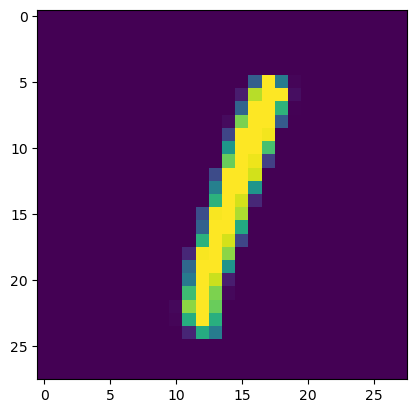

In [38]:
import matplotlib.pyplot as plt

plt.imshow(x_test[5])

In [39]:
y_test[5]

np.uint8(1)

In [40]:
x_test[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [41]:
# Scaling the data between 0 to 1
x_train = x_train/255.0
x_test = x_test/255.0

In [42]:
x_train.shape

(60000, 28, 28)

In [43]:
# on hot encoding for Labels
# Convert the shape of data to (60000,10)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [44]:
y_test[5]

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])

In [51]:
# Build the ANN
model = Sequential([
            Input(shape = (28,28)),
            Flatten(),
            Dense(256, activation = 'relu'),
            Dropout(0.2), # drop 20% of the neuron from previous layer
            Dense(128, activation = 'relu'),
            Dropout(0.2), # drop 20% of the neuron from previous layer
            Dense(64, activation = 'relu'),
            Dense(10, activation = 'softmax')
                  ])


In [52]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [53]:
model.fit(x_train, y_train, epochs = 10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9144 - loss: 0.2786
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9612 - loss: 0.1304
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9702 - loss: 0.0991
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9741 - loss: 0.0855
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9772 - loss: 0.0734
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9799 - loss: 0.0636
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9815 - loss: 0.0614
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9828 - loss: 0.0546
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9841 - loss: 0.0504
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9851 - loss: 0.0474


In [55]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(test_loss)
print(test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9790 - loss: 0.0797 
0.0796952173113823
0.9789999723434448


In [56]:
y_pred = model.predict(x_test)

print(y_test[0])
print(y_pred[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
[2.7072006e-11 6.6431824e-08 1.0016820e-06 2.4155761e-07 1.0521732e-08
 8.4433328e-12 3.6431321e-18 9.9999857e-01 1.0272459e-10 2.2289777e-07]


In [61]:
import numpy as np
# argmax function returns the index of highest element
y_pred_class = np.argmax(y_pred, axis = 1)
y_test_class = np.argmax(y_test, axis = 1)

In [65]:
for i in range(100):
    print(f" Predicted: {y_pred_class[i]}, Actual : {y_test_class[i]}")

 Predicted: 7, Actual : 7
 Predicted: 2, Actual : 2
 Predicted: 1, Actual : 1
 Predicted: 0, Actual : 0
 Predicted: 4, Actual : 4
 Predicted: 1, Actual : 1
 Predicted: 4, Actual : 4
 Predicted: 9, Actual : 9
 Predicted: 5, Actual : 5
 Predicted: 9, Actual : 9
 Predicted: 0, Actual : 0
 Predicted: 6, Actual : 6
 Predicted: 9, Actual : 9
 Predicted: 0, Actual : 0
 Predicted: 1, Actual : 1
 Predicted: 5, Actual : 5
 Predicted: 9, Actual : 9
 Predicted: 7, Actual : 7
 Predicted: 3, Actual : 3
 Predicted: 4, Actual : 4
 Predicted: 9, Actual : 9
 Predicted: 6, Actual : 6
 Predicted: 6, Actual : 6
 Predicted: 5, Actual : 5
 Predicted: 4, Actual : 4
 Predicted: 0, Actual : 0
 Predicted: 7, Actual : 7
 Predicted: 4, Actual : 4
 Predicted: 0, Actual : 0
 Predicted: 1, Actual : 1
 Predicted: 3, Actual : 3
 Predicted: 1, Actual : 1
 Predicted: 3, Actual : 3
 Predicted: 4, Actual : 4
 Predicted: 7, Actual : 7
 Predicted: 2, Actual : 2
 Predicted: 7, Actual : 7
 Predicted: 1, Actual : 1
 Predicted: 

Text(0.5, 1.0, ' Predicted: 7, Actual : 7')

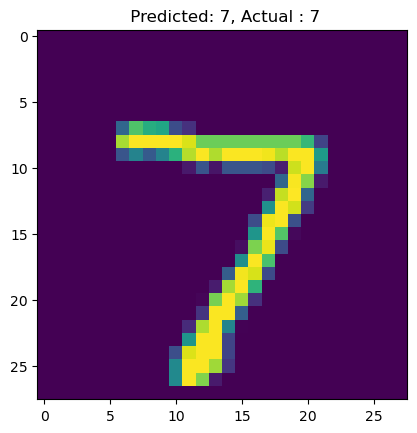

In [68]:
plt.imshow(x_test[0])
plt.title(f" Predicted: {y_pred_class[0]}, Actual : {y_test_class[0]}")

In [1]:
import tensorflow as tf

dir(tf.keras.activations)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'celu',
 'deserialize',
 'elu',
 'exponential',
 'gelu',
 'get',
 'glu',
 'hard_shrink',
 'hard_sigmoid',
 'hard_silu',
 'hard_swish',
 'hard_tanh',
 'leaky_relu',
 'linear',
 'log_sigmoid',
 'log_softmax',
 'mish',
 'relu',
 'relu6',
 'selu',
 'serialize',
 'sigmoid',
 'silu',
 'soft_shrink',
 'softmax',
 'softplus',
 'softsign',
 'sparse_plus',
 'sparse_sigmoid',
 'sparsemax',
 'squareplus',
 'swish',
 'tanh',
 'tanh_shrink',
 'threshold']

In [1]:
import tensorflow as tf

dir(tf.keras.optimizers)

['Adadelta',
 'Adafactor',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'Ftrl',
 'Lamb',
 'Lion',
 'LossScaleOptimizer',
 'Muon',
 'Nadam',
 'Optimizer',
 'RMSprop',
 'SGD',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'deserialize',
 'get',
 'legacy',
 'schedules',
 'serialize']

In [1]:
import tensorflow as tf

dir(tf.keras.losses)

['BinaryCrossentropy',
 'BinaryFocalCrossentropy',
 'CTC',
 'CategoricalCrossentropy',
 'CategoricalFocalCrossentropy',
 'CategoricalGeneralizedCrossEntropy',
 'CategoricalHinge',
 'Circle',
 'CosineSimilarity',
 'Dice',
 'Hinge',
 'Huber',
 'KLD',
 'KLDivergence',
 'LogCosh',
 'Loss',
 'MAE',
 'MAPE',
 'MSE',
 'MSLE',
 'MeanAbsoluteError',
 'MeanAbsolutePercentageError',
 'MeanSquaredError',
 'MeanSquaredLogarithmicError',
 'Poisson',
 'Reduction',
 'SparseCategoricalCrossentropy',
 'SquaredHinge',
 'Tversky',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'binary_crossentropy',
 'binary_focal_crossentropy',
 'categorical_crossentropy',
 'categorical_focal_crossentropy',
 'categorical_generalized_cross_entropy',
 'categorical_hinge',
 'circle',
 'cosine_similarity',
 'ctc',
 'deserialize',
 'dice',
 'get',
 'hinge',
 'huber',
 'kld',
 'kullback_leibler_divergence',
 'logcosh',
 'mae',
 'mape',
 'mse',
 'm

In [2]:
import tensorflow as tf

dir(tf.keras.metrics)

['AUC',
 'Accuracy',
 'BinaryAccuracy',
 'BinaryCrossentropy',
 'BinaryIoU',
 'CategoricalAccuracy',
 'CategoricalCrossentropy',
 'CategoricalHinge',
 'ConcordanceCorrelation',
 'CosineSimilarity',
 'F1Score',
 'FBetaScore',
 'FalseNegatives',
 'FalsePositives',
 'Hinge',
 'IoU',
 'KLD',
 'KLDivergence',
 'LogCoshError',
 'MAE',
 'MAPE',
 'MSE',
 'MSLE',
 'Mean',
 'MeanAbsoluteError',
 'MeanAbsolutePercentageError',
 'MeanIoU',
 'MeanMetricWrapper',
 'MeanSquaredError',
 'MeanSquaredLogarithmicError',
 'Metric',
 'OneHotIoU',
 'OneHotMeanIoU',
 'PearsonCorrelation',
 'Poisson',
 'Precision',
 'PrecisionAtRecall',
 'R2Score',
 'Recall',
 'RecallAtPrecision',
 'RootMeanSquaredError',
 'SensitivityAtSpecificity',
 'SparseCategoricalAccuracy',
 'SparseCategoricalCrossentropy',
 'SparseTopKCategoricalAccuracy',
 'SpecificityAtSensitivity',
 'SquaredHinge',
 'Sum',
 'TopKCategoricalAccuracy',
 'TrueNegatives',
 'TruePositives',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loa